# Compare market production methods (savegame)

Loads **format-2** `.pkl` snapshots from `analysis/savegame/notebooks/save_game_temp` (same pipeline as `compare_savegames_market.ipynb`): `locations` (already merged with region hierarchy), `buildings` (production methods per building), `market_goods`, etc.

**Recipe weights and PM slot groups** (food / drinks / packaging) are loaded from **`game_path` / `mod_path`** in your config via `BuildingData`—the same definitions as `production_method_comparison.ipynb`. Snapshots only store *which* PM each building uses; they do not embed recipe quantities.

Filters to one building type (default **`cookery`**, e.g. Prosper or Perish). Use `first_savegame` / `last_savegame` to slice snapshots (`last_savegame = 1` with `first_savegame = 0` for a single file).

**Global resource usage:** for the **latest** snapshot, three tables (**food** / **drinks** / **packaging**) list each trade **good** and **total_input** = sum over all cookery buildings of (recipe input parsed from `building_types` × buildings using that PM). PMs with no goods (e.g. well water, no packaging) contribute no rows. Locations are merged with **`LocationData`** (`merge_saves_with_location_data`) so **`macro_region`** is available; one column per macro region (slug as column name, same units as `total_input`), ordered by **descending column total** within that category so the largest regional footprints appear first. Missing macro region is bucketed as **`__unknown`**. Each table also includes **base_cost** (game `default_market_price` from merged goods definitions) and **total_cost** = `total_input` × `base_cost`.

**Global PM table:** counts how many cookery buildings use each `pp_cookery_*` method in the **latest** loaded snapshot (so totals are not multiplied when you load many time slices). Rows are grouped into **food**, **drinks**, and **packaging** to match the three `unique_production_methods` slots in the Prosper or Perish cookery building.

**Regional PM preferences:** three wide tables (`regional_prefs_food` / `regional_prefs_drinks` / `regional_prefs_packaging`) give, for each **macro region**, the **percentage share** of each production method in that slot as **whole-number** percentages (rows sum to ~100% per region); column names drop the `pp_cookery_` prefix for readability. PM columns are ordered by global usage in that slot (most common first).

**Regional spend mix:** three wide tables (`regional_spend_share_food` / `regional_spend_share_drinks` / `regional_spend_share_packaging`) show, for each **macro region**, the **percentage** of **base-price** cookery input spend (recipe quantity × `default_market_price` per trade good) allocated to each **good** in that slot; rows match regional PM ordering, good columns by descending global spend in that slot.

**Time-series plots:** when you load **multiple** snapshots, three line charts show how many buildings globally use each production method in the food, drink, and packaging slots over time (one line per `pp_cookery_*` method in that slot). The horizontal axis matches **`compare_savegames.ipynb`**: snapshot index 0, 1, … is labeled as **game years** (`start_year` 1337 + index × `years_per_snapshot` 5).

Pkls must include a **`buildings`** key (re-run the savegame watcher / processor with current ProsperPerishCalcs if yours were produced before that field existed).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from IPython.display import display

from core.parser.path_resolver import PathResolver
from core.data.building_data import BuildingData
from core.data.goods_data import GoodsData
from analysis.building_levels.building_analysis import load_config
from analysis.savegame import (
    buildings_df_from_pkl,
    locations_df_from_pkl,
    resolve_pkl_dir,
)
from analysis.savegame.datalocations import merge_saves_with_location_data

pd.options.display.max_columns = None
pd.options.display.width = 200

In [2]:
# Cookery: three UPM slots from parsed mod `building_types` (same source as production_method_comparison)
config = load_config()
path_resolver = PathResolver(config["game_path"], config["mod_path"])
building_data = BuildingData(path_resolver)
building_data.load_all()

goods_data = GoodsData(path_resolver)
goods_data.load_all()

cookery_maps = building_data.cookery_pm_maps("cookery")

_COOKERY_PM_FOOD = cookery_maps.food
_COOKERY_PM_DRINKS = cookery_maps.drinks
_COOKERY_PM_PACKAGING = cookery_maps.packaging
_COOKERY_PM_GOOD_INPUTS = cookery_maps.pm_good_inputs


def _cookery_pm_category(pm: str) -> str:
    return cookery_maps.category(pm)


In [3]:
"""Load .pkl snapshots (format-2 with market_goods + buildings)."""

# None = auto (newest playthrough under save_game_temp), or set path to your playthrough folder
PKL_PATH = None  # e.g. ".../save_game_temp/<playthrough_id>"
first_savegame = 0
last_savegame = None  # None = all; use 1 with first_savegame=0 for one snapshot only

pkl_dir = resolve_pkl_dir(PKL_PATH)
pkl_files = sorted(pkl_dir.glob("*.pkl"), key=lambda p: p.stem)
if last_savegame is not None:
    pkl_files = pkl_files[first_savegame:last_savegame]
else:
    pkl_files = pkl_files[first_savegame:]

raw = {p.stem: pd.read_pickle(p) for p in pkl_files}

for label, payload in raw.items():
    if not isinstance(payload, dict) or "market_goods" not in payload:
        raise TypeError(
            f"{label}: expected format-2 pkl with 'market_goods'. Got {type(payload).__name__}"
        )
    if "buildings" not in payload:
        raise ValueError(
            f"{label}: pkl has no 'buildings' key. Regenerate snapshots with the current "
            "savegame processor / watcher (format-2 now includes buildings)."
        )

_locations_merged = merge_saves_with_location_data(raw)

n_snap = len(raw)
print(f"Loaded {n_snap} snapshot(s) from {pkl_dir}")
print(f"Labels: {list(raw.keys())}")

Loaded 100 snapshot(s) from C:\Development\ProsperPerishCalcs\analysis\savegame\notebooks\save_game_temp\c2ea16f6_f1f4_4102_9989_09477a60d3af
Labels: ['20260401_181056', '20260401_181218', '20260401_181351', '20260401_181524', '20260401_181651', '20260401_181822', '20260401_181948', '20260401_182115', '20260401_182242', '20260401_182407', '20260401_182529', '20260401_182649', '20260401_182812', '20260401_182944', '20260401_183108', '20260401_183231', '20260401_183355', '20260401_183512', '20260401_183633', '20260401_183752', '20260401_183912', '20260401_184028', '20260401_184152', '20260401_184315', '20260401_184438', '20260401_184649', '20260401_190624', '20260401_190736', '20260401_190848', '20260401_191002', '20260401_191115', '20260401_191229', '20260401_191342', '20260401_191457', '20260401_191611', '20260401_191726', '20260401_191842', '20260401_191958', '20260401_192113', '20260401_192228', '20260401_192345', '20260401_192501', '20260401_192616', '20260401_192728', '20260401_192

In [4]:
# Building type to analyze (Prosper or Perish cookery); set to None to include all building types
BUILDING_SLUG = "cookery"

parts = []
for label, payload in raw.items():
    b = buildings_df_from_pkl(payload)
    if BUILDING_SLUG and "slug" in b.columns:
        b = b[b["slug"] == BUILDING_SLUG].copy()
    b["snapshot"] = label
    loc = _locations_merged.get(label)
    if not isinstance(loc, pd.DataFrame) or "location_id" not in loc.columns:
        loc = locations_df_from_pkl(payload)
    if "macro_region" not in loc.columns:
        for alias in ("macro_region_loc", "macro_region_pkl"):
            if alias in loc.columns:
                loc = loc.copy()
                loc["macro_region"] = loc[alias]
                break
    scope = [c for c in ("region", "macro_region", "super_region") if c in loc.columns]
    if "location_id" not in loc.columns or not scope:
        raise ValueError(f"{label}: locations frame missing location_id or scope columns.")
    # Omit location `slug` so it does not collide with building `slug`
    loc_sub = loc[["location_id", *scope]].drop_duplicates(subset=["location_id"])
    merged = b.merge(loc_sub, on="location_id", how="left", suffixes=("", "_loc"))
    parts.append(merged)

enriched = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
# if not enriched.empty:
#     display(enriched.head(20))
# else:
#     slug_msg = f"slug={BUILDING_SLUG!r}" if BUILDING_SLUG else "all slugs"
#     print(f"No matching buildings ({slug_msg}) in selected snapshot(s).")

In [5]:
# Global PM table (latest snapshot only)
if enriched.empty:
    pm_global = pd.DataFrame()
    print("No data for global PM counts.")
else:
    # Latest snapshot only: one world state, not N × duplicate buildings across time slices
    if "snapshot" in enriched.columns:
        _last_snap = sorted(enriched["snapshot"].astype(str).unique())[-1]
        _base = enriched[enriched["snapshot"] == _last_snap]
        print(f"Global PM counts use snapshot: {_last_snap}")
    else:
        _base = enriched

    pm_long = _base.explode("production_method_ids", ignore_index=True).rename(
        columns={"production_method_ids": "production_method"}
    )
    pm_long = pm_long[pm_long["production_method"].astype(str).str.startswith("pp_cookery_", na=False)]
    counts = pm_long["production_method"].value_counts()
    pm_global = counts.rename("building_uses").reset_index()
    pm_global.columns = ["production_method", "building_uses"]
    pm_global["category"] = pm_global["production_method"].map(_cookery_pm_category)
    _cat_order = {"food": 0, "drinks": 1, "packaging": 2, "other": 3}
    pm_global["_k"] = pm_global["category"].map(_cat_order)
    pm_global = (
        pm_global.sort_values(["_k", "building_uses", "production_method"], ascending=[True, False, True])
        .drop(columns=["_k"])
        .reset_index(drop=True)
    )
    display(pm_global)
    cat_totals = (
        pm_global.groupby("category", sort=False)["building_uses"]
        .sum()
        .reindex(["food", "drinks", "packaging", "other"], fill_value=0)
        .rename("sum_building_uses")
        .to_frame()
    )
    display(cat_totals)

Global PM counts use snapshot: 20260401_210018


,production_method,building_uses,category
0,pp_cookery_labskaus,609,food
1,pp_cookery_pemmican,413,food
2,pp_cookery_ika_mata,412,food
3,pp_cookery_mutton_and_pease,394,food
4,pp_cookery_livestock_pottage,300,food
5,pp_cookery_fish_congee,273,food
6,pp_cookery_pozole,253,food
7,pp_cookery_mediterranean_fish,191,food
8,pp_cookery_khichdi,171,food
9,pp_cookery_honey_gruel,156,food


,sum_building_uses
category,
food,3625
drinks,3625
packaging,3625
other,0


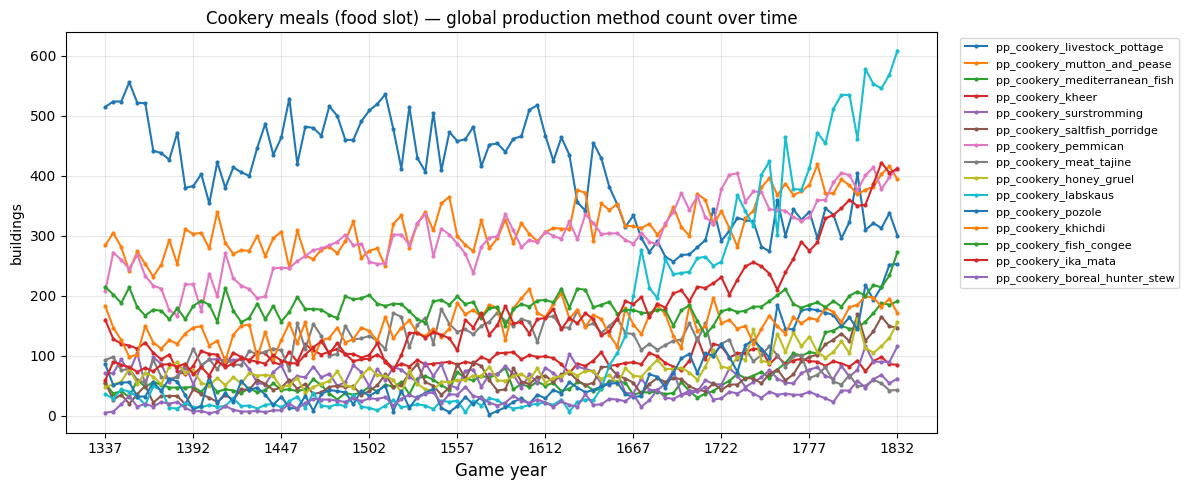

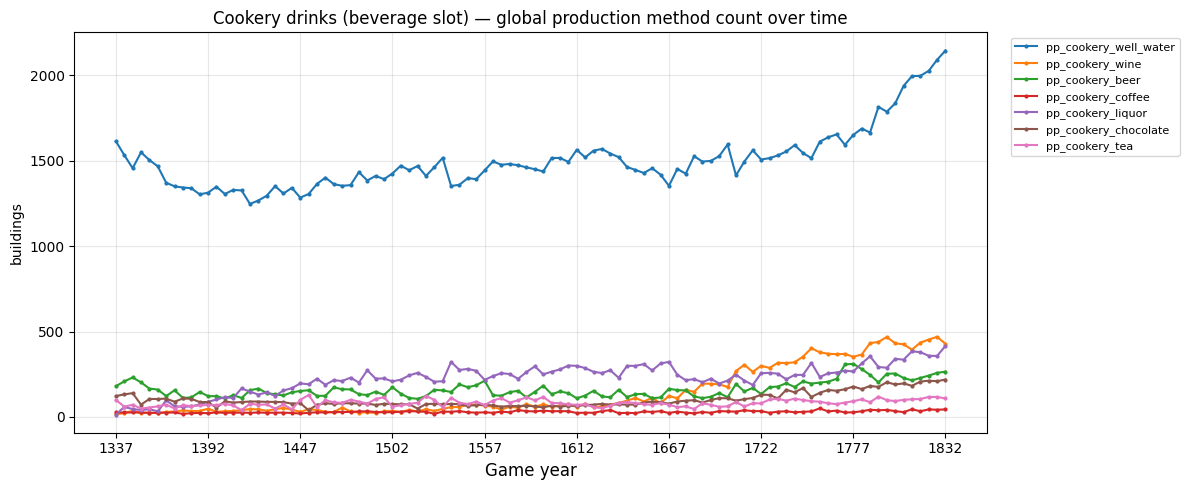

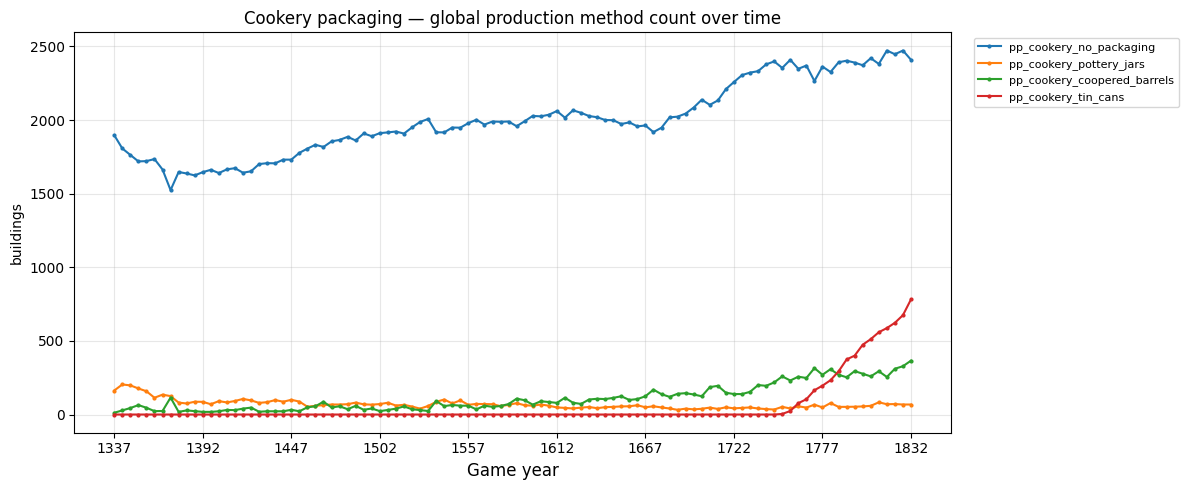

In [6]:
# Time series: global cookery PM counts per snapshot (meals / drinks / packaging slots)
if enriched.empty or "snapshot" not in enriched.columns:
    print("No time-series data (need non-empty enriched with snapshot).")
else:
    pm_ts = enriched.explode("production_method_ids", ignore_index=True).rename(
        columns={"production_method_ids": "production_method"}
    )
    pm_ts = pm_ts[pm_ts["production_method"].astype(str).str.startswith("pp_cookery_", na=False)]
    pm_ts["category"] = pm_ts["production_method"].map(_cookery_pm_category)
    pm_ts = pm_ts[pm_ts["category"] != "other"]
    if pm_ts.empty:
        print("No pp_cookery_* production methods to plot.")
    else:
        counts = (
            pm_ts.groupby(["snapshot", "category", "production_method"], sort=False)
            .size()
            .rename("n")
        )
        snap_order = sorted(enriched["snapshot"].astype(str).unique())
        # X-axis: same convention as compare_savegames.ipynb (snapshot index -> game year)
        years_per_snapshot = 5
        start_year = 1337  # EU5 start
        n_ticks = 10
        n = len(snap_order)
        x_pos = list(range(n))
        if n <= 1:
            tick_positions = list(range(n))
        elif n <= n_ticks:
            tick_positions = list(range(n))
        else:
            step = (n - 1) / (n_ticks - 1)
            tick_positions = [int(round(i * step)) for i in range(n_ticks)]
        tick_labels = [start_year + pos * years_per_snapshot for pos in tick_positions]

        _slot_titles = {
            "food": "Cookery meals (food slot) — global production method count over time",
            "drinks": "Cookery drinks (beverage slot) — global production method count over time",
            "packaging": "Cookery packaging — global production method count over time",
        }
        for cat in ("food", "drinks", "packaging"):
            try:
                sub = counts.xs(cat, level="category")
            except KeyError:
                print(f"Skip time-series plot: no rows for category {cat!r}.")
                continue
            wide = sub.unstack(level="production_method", fill_value=0)
            wide = wide.reindex(snap_order).fillna(0).astype(int)
            if wide.empty:
                print(f"Skip time-series plot: empty pivot for {cat!r}.")
                continue
            fig, ax = plt.subplots(figsize=(12, 5))
            for col in wide.columns:
                ax.plot(x_pos, wide[col].values, label=col, marker="o", markersize=2)
            ax.set_title(_slot_titles[cat])
            ax.set_ylabel("buildings")
            ax.set_xlabel("Game year", fontsize=12)
            ax.tick_params(axis="both", labelsize=10)
            ax.grid(True, axis="both", alpha=0.3, linestyle="-")
            ax.set_xticks(tick_positions)
            ax.set_xticklabels(tick_labels)
            ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
            fig.tight_layout()
            plt.show()

In [7]:
# Global trade-good input usage (latest snapshot), by slot category — recipe inputs from
# Parsed per-PM trade-good inputs (_COOKERY_PM_GOOD_INPUTS) × count of cookery buildings using each PM.
if enriched.empty:
    print("No data for global resource usage.")
else:
    if "snapshot" in enriched.columns:
        _last_snap = sorted(enriched["snapshot"].astype(str).unique())[-1]
        _base = enriched[enriched["snapshot"] == _last_snap]
        print(f"Global resource usage — snapshot {_last_snap}")
    else:
        _base = enriched
    ex = _base.explode("production_method_ids", ignore_index=True).rename(
        columns={"production_method_ids": "production_method"}
    )
    ex = ex[ex["production_method"].astype(str).str.startswith("pp_cookery_", na=False)]
    if ex.empty:
        print("No pp_cookery_* production methods in this slice.")
    else:
        def _mr_col_suffix(mr):
            if pd.isna(mr):
                return "__unknown"
            return str(mr).strip().replace(" ", "_")

        pm_counts = ex["production_method"].value_counts()
        if "macro_region" in ex.columns:
            _mr_levels = sorted(
                {_mr_col_suffix(mr) for mr, _ in ex.groupby("macro_region", dropna=False)}
            )
        else:
            _mr_levels = []
            print(
                "No macro_region on building rows; omitting per-macro_region columns "
                "(use merged locations / pkls with hierarchy)."
            )
        for cat in ("food", "drinks", "packaging"):
            totals = defaultdict(float)
            for pm, n in pm_counts.items():
                if _cookery_pm_category(pm) != cat:
                    continue
                for good, qty in _COOKERY_PM_GOOD_INPUTS.get(pm, {}).items():
                    totals[good] += float(n) * float(qty)
            if not totals:
                print(f"\n{cat}: no trade-good inputs (empty recipe or no buildings).")
                continue
            totals_reg = defaultdict(lambda: defaultdict(float))
            if _mr_levels:
                for mr, ex_mr in ex.groupby("macro_region", dropna=False):
                    mk = _mr_col_suffix(mr)
                    pm_counts_mr = ex_mr["production_method"].value_counts()
                    for pm, n in pm_counts_mr.items():
                        if _cookery_pm_category(pm) != cat:
                            continue
                        for good, qty in _COOKERY_PM_GOOD_INPUTS.get(pm, {}).items():
                            totals_reg[good][mk] += float(n) * float(qty)
            df = pd.DataFrame(
                sorted(totals.items(), key=lambda kv: -kv[1]),
                columns=["good", "total_input"],
            )
            df["total_input"] = df["total_input"].round(2)
            df.insert(0, "category", cat)
            if _mr_levels:
                mr_cols = list(_mr_levels)
                for mrk in mr_cols:
                    df[mrk] = [
                        round(totals_reg[g].get(mrk, 0.0), 2) for g in df["good"]
                    ]
                _mr_order = df[mr_cols].sum().sort_values(ascending=False).index.tolist()
                df = df[["category", "good", "total_input", *_mr_order]]
            df["base_cost"] = df["good"].map(goods_data.modded_df["default_market_price"])
            df["total_cost"] = (df["total_input"] * df["base_cost"]).round(2)
            if _mr_levels:
                df = df[["category", "good", "total_input", "total_cost", "base_cost", *_mr_order]]
            else:
                df = df[["category", "good", "total_input", "total_cost", "base_cost"]]
            _missing = df.loc[df["base_cost"].isna(), "good"].tolist()
            if _missing:
                print(f"  Warning: no default_market_price in merged goods for: {_missing}")
            print(f"\n--- {cat} ---")
            display(df)

Global resource usage — snapshot 20260401_210018

--- food ---


,category,good,total_input,total_cost,base_cost,western_europe,east_asia,eastern_europe,south_east_asia,south_asia,south_america,north_america,middle_east,west_africa,east_africa,central_africa,north_africa,southern_africa,central_asia,australasia,pacific_islands
0,food,fish,5376.29,5376.29,1.00,1088.48,728.32,550.10,645.61,230.99,431.94,399.11,204.48,329.81,232.36,82.81,254.94,97.38,3.00,24.96,72.00
1,food,livestock,3202.63,4803.94,1.50,872.44,454.26,524.02,40.16,236.09,100.58,62.11,221.71,222.51,123.49,134.22,35.19,71.69,68.70,32.64,2.82
2,food,wild_game,2516.30,2516.30,1.00,365.00,505.60,233.30,52.10,211.70,328.40,269.80,94.50,45.00,38.60,189.70,2.60,54.00,13.50,99.00,13.50
3,food,fruit,1759.84,1759.84,1.00,305.11,183.06,87.22,218.95,122.12,217.69,187.00,88.81,63.20,86.03,61.00,13.18,27.00,26.97,24.50,48.00
4,food,rice,1745.70,1745.70,1.00,42.90,861.30,26.40,316.80,254.10,16.50,16.50,52.80,56.10,82.50,3.30,3.30,6.60,6.60,0.00,0.00
5,food,wool,1398.70,1748.38,1.25,670.95,60.35,241.40,3.55,67.45,56.80,39.05,181.05,21.30,0.00,10.65,21.30,0.00,21.30,0.00,3.55
6,food,legumes,1337.43,1337.43,1.00,389.61,379.30,165.55,89.44,65.47,32.50,18.48,124.41,24.36,10.61,5.04,13.54,0.00,17.44,0.00,1.68
7,food,wheat,1334.40,1334.40,1.00,468.00,297.60,188.80,15.20,115.20,26.40,0.00,101.60,28.80,55.20,0.00,8.00,0.00,29.60,0.00,0.00
8,food,potato,572.46,572.46,1.00,210.56,35.72,118.44,7.52,12.22,9.40,15.98,31.02,55.46,12.22,30.08,10.34,17.86,1.88,3.76,0.00
9,food,millet,560.72,560.72,1.00,172.30,64.62,96.47,69.82,13.47,33.24,9.99,0.94,24.28,30.23,0.00,3.76,31.20,0.00,10.40,0.00



--- drinks ---


,category,good,total_input,total_cost,base_cost,western_europe,east_asia,eastern_europe,south_east_asia,south_asia,west_africa,middle_east,south_america,north_america,east_africa,north_africa,central_africa,central_asia,southern_africa,pacific_islands,australasia
0,drinks,wine,898.80,1797.6,2.0,453.6,29.4,100.80,35.70,31.50,35.70,56.70,65.10,18.9,21.00,29.4,6.30,6.3,8.4,0.0,0.0
1,drinks,liquor,686.40,1716.0,2.5,158.4,108.9,61.05,95.70,89.10,59.40,49.50,8.25,9.9,9.90,19.8,3.30,13.2,0.0,0.0,0.0
2,drinks,beer,516.75,1033.5,2.0,159.9,81.9,62.40,48.75,54.60,29.25,33.15,5.85,7.8,1.95,15.6,3.90,7.8,0.0,3.9,0.0
3,drinks,cocoa,175.20,700.8,4.0,0.0,0.0,0.00,0.00,0.00,24.80,0.00,44.00,60.0,8.80,0.0,31.20,0.0,6.4,0.0,0.0
4,drinks,tea,145.80,437.4,3.0,0.0,140.4,0.00,4.05,1.35,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0
5,drinks,coffee,46.20,138.6,3.0,0.0,0.0,0.00,0.00,0.00,0.00,4.20,4.20,2.1,32.55,0.0,3.15,0.0,0.0,0.0,0.0



--- packaging ---


,category,good,total_input,total_cost,base_cost,western_europe,east_asia,eastern_europe,south_america,south_east_asia,west_africa,north_america,central_africa,south_asia,north_africa,east_africa,middle_east,southern_africa,pacific_islands,central_asia,australasia
0,packaging,steel,782.0,3910.0,5.0,260.0,66.0,142.0,83.0,18.0,50.0,23.0,46.0,7.0,26.0,26.0,21.0,13.0,0.0,1.0,0.0
1,packaging,furniture,329.4,988.2,3.0,73.8,60.3,5.4,54.0,54.0,20.7,18.9,6.3,24.3,3.6,2.7,3.6,0.0,1.8,0.0,0.0
2,packaging,pottery,190.4,190.4,1.0,33.6,47.6,16.8,16.8,22.4,8.4,25.2,0.0,19.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
# Regional PM preferences (latest snapshot): per macro-region % share of each slot's PM assignments.
import numpy as np


def _mr_col_suffix_prefs(mr):
    if pd.isna(mr):
        return "__unknown"
    return str(mr).strip().replace(" ", "_")


regional_prefs_food = pd.DataFrame()
regional_prefs_drinks = pd.DataFrame()
regional_prefs_packaging = pd.DataFrame()

if enriched.empty:
    print("No data for regional PM preferences.")
else:
    if "snapshot" in enriched.columns:
        _last_snap = sorted(enriched["snapshot"].astype(str).unique())[-1]
        _base_pref = enriched[enriched["snapshot"] == _last_snap]
    else:
        _base_pref = enriched
    ex_pref = _base_pref.explode("production_method_ids", ignore_index=True).rename(
        columns={"production_method_ids": "production_method"}
    )
    ex_pref = ex_pref[ex_pref["production_method"].astype(str).str.startswith("pp_cookery_", na=False)]
    if "macro_region" not in ex_pref.columns:
        print("No macro_region; skipping regional PM preference tables.")
    elif ex_pref.empty:
        print("No pp_cookery_* rows for regional PM preferences.")
    else:
        ex_pref = ex_pref.copy()
        ex_pref["_mr"] = ex_pref["macro_region"].map(_mr_col_suffix_prefs)

        _mr_cookery_order = (
            _base_pref.assign(_mr=_base_pref["macro_region"].map(_mr_col_suffix_prefs))
            .groupby("_mr", observed=False)
            .size()
            .sort_values(ascending=False)
            .index.tolist()
        )

        def _regional_pm_pct(cat: str, mr_order: list) -> pd.DataFrame:
            sub = ex_pref[ex_pref["production_method"].map(_cookery_pm_category) == cat]
            if sub.empty:
                return pd.DataFrame()
            ct = sub.groupby(["_mr", "production_method"], observed=False).size().unstack(fill_value=0)
            denom = ct.sum(axis=1).replace(0, np.nan)
            pct = (ct.div(denom, axis=0) * 100).fillna(0)
            col_order = ct.sum(axis=0).sort_values(ascending=False).index.tolist()
            pct = pct.reindex(columns=col_order)
            pct.columns = [str(c).removeprefix("pp_cookery_") for c in pct.columns]
            pct = np.rint(pct).astype(int)
            idx = [i for i in mr_order if i in pct.index]
            idx.extend([i for i in pct.index if i not in idx])
            return pct.loc[idx] if len(idx) else pct

        regional_prefs_food = _regional_pm_pct("food", _mr_cookery_order)
        regional_prefs_drinks = _regional_pm_pct("drinks", _mr_cookery_order)
        regional_prefs_packaging = _regional_pm_pct("packaging", _mr_cookery_order)

        for _slot_name, _sdf in (
            ("food", regional_prefs_food),
            ("drinks", regional_prefs_drinks),
            ("packaging", regional_prefs_packaging),
        ):
            print(f"\n--- {_slot_name} — regional PM % (rows sum to ~100 per macro region) ---")
            if _sdf.empty:
                display(_sdf)
            else:
                display(
                    _sdf.style.background_gradient(
                        cmap="Greens", axis=1, low=0.05, high=0.95
                    )
                    .set_properties(**{"text-align": "center"})
                    .set_table_styles(
                        [{"selector": "th", "props": [("text-align", "center")]}],
                        overwrite=False,
                    )
                )


--- food — regional PM % (rows sum to ~100 per macro region) ---


,labskaus,pemmican,ika_mata,mutton_and_pease,livestock_pottage,fish_congee,pozole,mediterranean_fish,khichdi,honey_gruel,saltfish_porridge,surstromming,kheer,boreal_hunter_stew,meat_tajine
_mr,,,,,,,,,,,,,,,
western_europe,25,4,5,21,8,0,9,7,1,11,6,1,0,1,0
east_asia,6,17,4,3,15,23,2,4,17,1,0,1,2,4,0
eastern_europe,29,6,4,16,12,0,10,9,1,2,5,0,0,5,0
south_east_asia,3,5,34,0,0,26,0,1,13,2,11,3,1,0,0
south_asia,6,19,10,8,13,13,3,0,2,3,2,0,18,0,2
south_america,4,28,24,7,0,0,9,2,1,5,3,14,1,0,1
north_america,8,6,32,5,0,2,38,0,0,0,0,8,0,0,0
middle_east,17,11,8,26,13,1,0,8,4,5,0,1,3,0,5
west_africa,39,7,13,4,6,6,0,1,2,0,3,16,3,0,1



--- drinks — regional PM % (rows sum to ~100 per macro region) ---


,well_water,wine,liquor,beer,chocolate,tea,coffee
_mr,,,,,,,
western_europe,56,24,11,9,0,0,0
east_asia,63,2,11,7,0,17,0
eastern_europe,73,11,9,7,0,0,0
south_east_asia,57,7,24,11,0,1,0
south_asia,58,6,23,12,0,0,0
south_america,56,14,2,1,25,0,2
north_america,56,4,3,2,35,0,1
middle_east,61,14,15,9,0,0,2
west_africa,35,11,24,10,20,0,0



--- packaging — regional PM % (rows sum to ~100 per macro region) ---


,no_packaging,tin_cans,coopered_barrels,pottery_jars
_mr,,,,
western_europe,61,29,9,1
east_asia,76,11,11,3
eastern_europe,65,33,1,1
south_east_asia,64,8,25,3
south_asia,82,3,12,3
south_america,33,37,27,3
north_america,75,11,10,4
middle_east,87,11,2,0
west_africa,50,33,15,2


In [9]:
# Regional spend mix (latest snapshot): % of base-price cookery input spend per trade good, per slot.
import numpy as np
from collections import defaultdict


def _mr_col_suffix_spend(mr):
    if pd.isna(mr):
        return "__unknown"
    return str(mr).strip().replace(" ", "_")


regional_spend_share_food = pd.DataFrame()
regional_spend_share_drinks = pd.DataFrame()
regional_spend_share_packaging = pd.DataFrame()

if enriched.empty:
    print("No data for regional spend mix.")
else:
    if "snapshot" in enriched.columns:
        _last_snap = sorted(enriched["snapshot"].astype(str).unique())[-1]
        _base_spend = enriched[enriched["snapshot"] == _last_snap]
    else:
        _base_spend = enriched
    ex_s = _base_spend.explode("production_method_ids", ignore_index=True).rename(
        columns={"production_method_ids": "production_method"}
    )
    ex_s = ex_s[ex_s["production_method"].astype(str).str.startswith("pp_cookery_", na=False)]
    if "macro_region" not in ex_s.columns:
        print("No macro_region; skipping regional spend mix tables.")
    elif ex_s.empty:
        print("No pp_cookery_* rows for regional spend mix.")
    else:
        ex_s = ex_s.copy()
        ex_s["_mr"] = ex_s["macro_region"].map(_mr_col_suffix_spend)

        _mr_cookery_order_spend = (
            _base_spend.assign(_mr=_base_spend["macro_region"].map(_mr_col_suffix_spend))
            .groupby("_mr", observed=False)
            .size()
            .sort_values(ascending=False)
            .index.tolist()
        )

        _price = goods_data.modded_df["default_market_price"]

        spend_food = defaultdict(lambda: defaultdict(float))
        spend_drinks = defaultdict(lambda: defaultdict(float))
        spend_packaging = defaultdict(lambda: defaultdict(float))
        missing_price = set()

        for mr, ex_mr in ex_s.groupby("macro_region", dropna=False):
            mk = _mr_col_suffix_spend(mr)
            pm_counts_mr = ex_mr["production_method"].value_counts()
            for pm, n in pm_counts_mr.items():
                cat = _cookery_pm_category(pm)
                if cat == "food":
                    tgt = spend_food
                elif cat == "drinks":
                    tgt = spend_drinks
                elif cat == "packaging":
                    tgt = spend_packaging
                else:
                    continue
                for good, qty in _COOKERY_PM_GOOD_INPUTS.get(pm, {}).items():
                    if good not in _price.index:
                        missing_price.add(good)
                        continue
                    p = float(_price.loc[good])
                    if pd.isna(p):
                        missing_price.add(good)
                        continue
                    tgt[mk][good] += float(n) * float(qty) * p

        if missing_price:
            print(f"  Warning: default_market_price missing for goods: {sorted(missing_price)}")

        def _spend_dict_to_pct(spend, mr_order):
            if not spend:
                return pd.DataFrame()
            rows = sorted(spend.keys())
            goods = sorted({g for r in spend for g in spend[r]})
            df_raw = pd.DataFrame(
                {g: [spend[mk].get(g, 0.0) for mk in rows] for g in goods},
                index=rows,
            )
            denom = df_raw.sum(axis=1).replace(0, np.nan)
            pct = (df_raw.div(denom, axis=0) * 100).fillna(0)
            pct = np.rint(pct).astype(int)
            col_order = df_raw.sum(axis=0).sort_values(ascending=False).index.tolist()
            pct = pct.reindex(columns=col_order)
            idx = [i for i in mr_order if i in pct.index]
            idx.extend([i for i in pct.index if i not in idx])
            return pct.loc[idx] if len(idx) else pct

        regional_spend_share_food = _spend_dict_to_pct(spend_food, _mr_cookery_order_spend)
        regional_spend_share_drinks = _spend_dict_to_pct(spend_drinks, _mr_cookery_order_spend)
        regional_spend_share_packaging = _spend_dict_to_pct(spend_packaging, _mr_cookery_order_spend)

        for _slot_name, _sdf in (
            ("food", regional_spend_share_food),
            ("drinks", regional_spend_share_drinks),
            ("packaging", regional_spend_share_packaging),
        ):
            print(f"\n--- {_slot_name} — regional spend mix % at base prices (per good) ---")
            if _sdf.empty:
                display(_sdf)
            else:
                display(
                    _sdf.style.background_gradient(
                        cmap="Greens", axis=1, low=0.05, high=0.95
                    )
                    .set_properties(**{"text-align": "center"})
                    .set_table_styles(
                        [{"selector": "th", "props": [("text-align", "center")]}],
                        overwrite=False,
                    )
                )


--- food — regional spend mix % at base prices (per good) ---


,fish,livestock,wild_game,fruit,wool,rice,legumes,wheat,salt,potato,beeswax,millet,maize,chili,olives,fur,pepper,sugar,wine,saffron
western_europe,17,21,6,5,13,1,6,7,5,3,6,3,3,3,1,1,0,0,0,0
east_asia,17,16,12,4,2,20,9,7,2,1,0,2,1,1,1,3,3,0,0,0
eastern_europe,18,26,8,3,10,1,5,6,4,4,1,3,3,3,2,3,0,0,1,0
south_east_asia,39,4,3,13,0,19,5,1,5,0,1,4,0,0,0,0,3,0,0,0
south_asia,14,22,13,8,5,16,4,7,2,1,2,1,1,1,0,0,1,2,0,0
south_america,27,10,21,14,5,1,2,2,8,1,3,2,2,2,0,0,0,0,0,0
north_america,27,6,18,13,3,1,1,0,6,1,0,1,11,11,0,0,0,0,0,0
middle_east,15,24,7,6,16,4,9,7,5,2,2,0,0,0,2,0,0,0,0,1
west_africa,31,31,4,6,2,5,2,3,7,5,0,2,0,0,0,0,1,0,0,0
east_africa,28,22,5,10,0,10,1,7,5,1,3,4,0,0,0,0,1,1,0,1



--- drinks — regional spend mix % at base prices (per good) ---


,wine,liquor,beer,cocoa,tea,coffee
western_europe,56,24,20,0,0,0
east_asia,6,30,18,0,46,0
eastern_europe,42,32,26,0,0,0
south_east_asia,17,57,23,0,3,0
south_asia,16,56,27,0,1,0
south_america,37,6,3,50,0,4
north_america,12,8,5,74,0,2
middle_east,36,39,21,0,0,4
west_africa,19,39,15,26,0,0
east_africa,21,12,2,17,0,48



--- packaging — regional spend mix % at base prices (per good) ---


,steel,furniture,pottery
western_europe,84,14,2
east_asia,59,32,9
eastern_europe,96,2,2
south_east_asia,33,59,8
south_asia,27,57,15
south_america,70,27,3
north_america,58,29,13
middle_east,91,9,0
west_africa,78,19,3
east_africa,94,6,0
